# Séries Temporais

## Análise Exploratória:
**Objetivo:** Desenvolver um modelo de séries temporais capaz de prever o preço de fechamento (`Close`) de uma ação na bolsa, utilizando como base o histórico de preços disponíveis.

## 1. Carregamento

In [2]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import utils as ut

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
train_raw, test_raw = ut.load_raw("../data/raw")

## 2. Qualidade dos dados

In [4]:
print(f"Treino (raw): {len(train_raw)} linhas | Período: {train_raw['Date'].min().date()} a {train_raw['Date'].max().date()}")
print(f"Teste (raw):  {len(test_raw)} linhas | Período: {test_raw['Date'].min().date()} a {test_raw['Date'].max().date()}")

Treino (raw): 1345 linhas | Período: 2013-01-02 a 2018-05-25
Teste (raw):  19 linhas | Período: 2018-05-28 a 2018-06-22


### Tipos

In [5]:
train_raw.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.9900,20.2100,19.6900,19.6900,18.0863,"30,182,600.0000"
1,2013-01-03,19.8100,20.4000,19.7000,20.4000,18.7384,"30,552,600.0000"
2,2013-01-04,20.3300,20.6200,20.1700,20.4300,18.7660,"36,141,000.0000"
3,2013-01-07,20.4800,20.6700,19.9500,20.0800,18.4445,"28,069,600.0000"
4,2013-01-08,20.1100,20.2300,19.4600,19.5000,17.9117,"29,091,300.0000"


In [6]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1345 non-null   datetime64[us]
 1   Open       1342 non-null   float64       
 2   High       1342 non-null   float64       
 3   Low        1342 non-null   float64       
 4   Close      1342 non-null   float64       
 5   Adj Close  1342 non-null   float64       
 6   Volume     1342 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 73.7 KB


In [7]:
test_raw.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-05-28,19.2000,19.2000,16.9100,16.9100,16.9100,134504900
1,2018-05-29,18.0000,19.4400,17.6000,19.3000,19.3000,181509800
2,2018-05-30,18.3900,19.9700,18.1300,18.9800,18.9800,125430000
3,2018-06-01,19.5600,19.7500,14.9000,16.1600,16.1600,216954700
4,2018-06-04,17.2900,17.6400,17.0500,17.5300,17.5300,93547600


In [8]:
test_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       19 non-null     datetime64[us]
 1   Open       19 non-null     float64       
 2   High       19 non-null     float64       
 3   Low        19 non-null     float64       
 4   Close      19 non-null     float64       
 5   Adj Close  19 non-null     float64       
 6   Volume     19 non-null     int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 1.2 KB


### Nulos

In [9]:
missing = train_raw.isna().sum()
print("Valores ausentes por coluna (treino, raw):")
print(missing[missing > 0] if missing.sum() else "Nenhum ausente isolado, veja as linhas 100% vazias abaixo:")

linhas_vazias = train_raw[train_raw["Close"].isna()]
print("\nLinhas totalmente vazias:")
linhas_vazias

Valores ausentes por coluna (treino, raw):
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       3
dtype: int64

Linhas totalmente vazias:


,Date,Open,High,Low,Close,Adj Close,Volume
58,2013-03-28,NaN,NaN,NaN,NaN,NaN,NaN
78,2013-04-26,NaN,NaN,NaN,NaN,NaN,NaN
140,2013-07-26,NaN,NaN,NaN,NaN,NaN,NaN


3 datas com todas as colunas vazias: 28/03/2013, 26/04/2013 e 26/07/2013.

### Duplicatas

In [10]:
print(f"Datas duplicadas no treino: {train_raw['Date'].duplicated().sum()}")
print(f"Datas duplicadas no teste:  {test_raw['Date'].duplicated().sum()}")

Datas duplicadas no treino: 0
Datas duplicadas no teste:  0


### Sobreposição treino/teste

In [11]:
overlap = set(train_raw["Date"]).intersection(set(test_raw["Date"]))
print(f"Datas sobrepostas entre treino e teste: {len(overlap)}")

Datas sobrepostas entre treino e teste: 0


## 3. Limpeza

As 3 datas com todas as colunas vazias são interpoladas linearmente a partir dos dias adjacentes.

In [12]:
train, test = ut.clean_and_save(train_raw, test_raw, "../data/processed")
assert train["Close"].isna().sum() == 0
print("Dados limpos e salvos em data/processed/. Shapes:", train.shape, test.shape)

Dados limpos e salvos em data/processed/. Shapes: (1345, 7) (19, 7)


## 4. Estrutura temporal

In [13]:
full = ut.make_full_series(train, test)

full_bdays = pd.bdate_range(train["Date"].min(), train["Date"].max())
missing_bdays = full_bdays.difference(train["Date"])
diffs = train["Date"].diff().dt.days.dropna()

print(f"Dias úteis esperados no período de treino: {len(full_bdays)}")
print(f"Dias úteis ausentes: {len(missing_bdays)}")
print(f"Maior intervalo entre pregões consecutivos: {int(diffs.max())} dias corridos")

Dias úteis esperados no período de treino: 1408
Dias úteis ausentes: 63
Maior intervalo entre pregões consecutivos: 5 dias corridos


63 dias úteis não aparecem no período de treino. O maior intervalo entre dois pregões seguidos foi de 5 dias corridos.

## 5. Análise da variável alvo

### Estatísticas

In [14]:
train["Close"].describe()

count   1,345.0000
mean       14.5473
std         4.4366
min         4.2000
25%        11.5800
50%        15.0200
75%        17.8300
max        27.3900
Name: Close, dtype: float64

### Outliers

In [15]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lo) | (s > hi)]

print("Outliers de Close (IQR):", len(iqr_outliers(train["Close"])))
print("Outliers de Volume (IQR):", len(iqr_outliers(train["Volume"])))

Outliers de Close (IQR): 1
Outliers de Volume (IQR): 41


1 outlier em Close pelo critério IQR.

Volume foi inspecionado apenas como variável auxiliar. 

Os 41 outliers de Volume por IQR não são tratados, porque Volume não entra nos modelos univariados de previsão de Close (indicando períodos com movimentação muito acima do padrão da série).

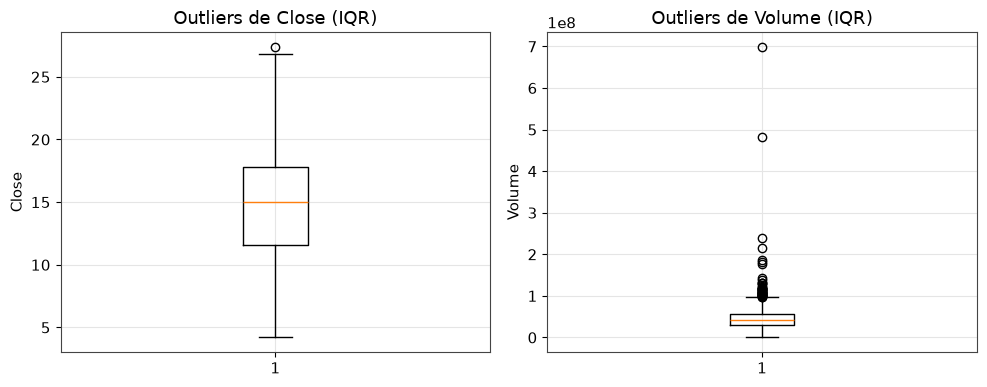

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Close
axes[0].boxplot(train["Close"].dropna())
axes[0].set_title("Outliers de Close (IQR)")
axes[0].set_ylabel("Close")

# Volume
axes[1].boxplot(train["Volume"].dropna())
axes[1].set_title("Outliers de Volume (IQR)")
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

### Retornos

In [17]:
retorno = train["Close"].pct_change()
retorno.describe()

count   1,344.0000
mean        0.0005
std         0.0319
min        -0.1576
25%        -0.0178
50%         0.0000
75%         0.0172
max         0.1628
Name: Close, dtype: float64

Os retornos são próximos de zero em média, mas apresentam alta variabilidade, com oscilações de até aproximadamente ±16%.

### Choques

In [18]:
choques = train[retorno.abs() > 4 * retorno.std()][["Date", "Close"]].assign(
    retorno=retorno[retorno.abs() > 4 * retorno.std()]
)
print("Choques de retorno diário acima de 4 desvios-padrão:")
choques

Choques de retorno diário acima de 4 desvios-padrão:


,Date,Close,retorno
518,2015-02-03,9.9700,0.1342
774,2016-02-22,5.0400,0.1300
782,2016-03-03,6.5700,0.1628
1083,2017-05-18,13.1500,-0.1576
1343,2018-05-24,20.0800,-0.1371


Foram identificados 5 choques de retorno, com variações diárias muito acima do comportamento habitual da série, tanto de alta quanto de queda.

## 6. Visualização do Close

### Série completa

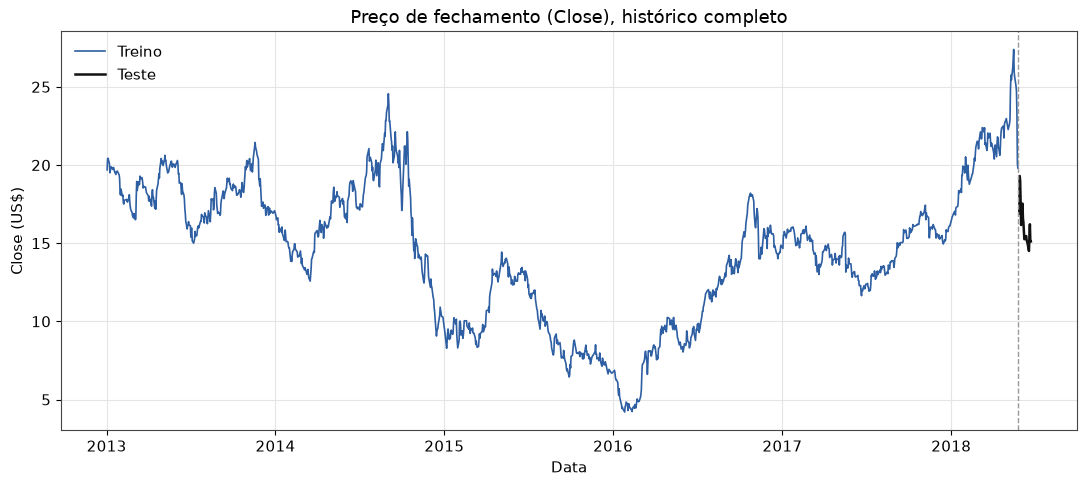

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train["Date"], train["Close"], color=ut.PALETTE["treino"], linewidth=1.2, label="Treino")
ax.plot(test["Date"], test["Close"], color=ut.PALETTE["real"], linewidth=1.8, label="Teste")
ax.axvline(train["Date"].max(), color="#999999", linestyle="--", linewidth=1)
ax.set_title("Preço de fechamento (Close), histórico completo")
ax.set_xlabel("Data"); ax.set_ylabel("Close (US$)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

O preço apresenta alta volatilidade, com períodos de queda e recuperação. Há uma tendência de alta a partir de 2016, atingindo um pico próximo de US$ 27 em 2018, seguido por uma queda acentuada no período de teste.


### Zoom: treino → teste

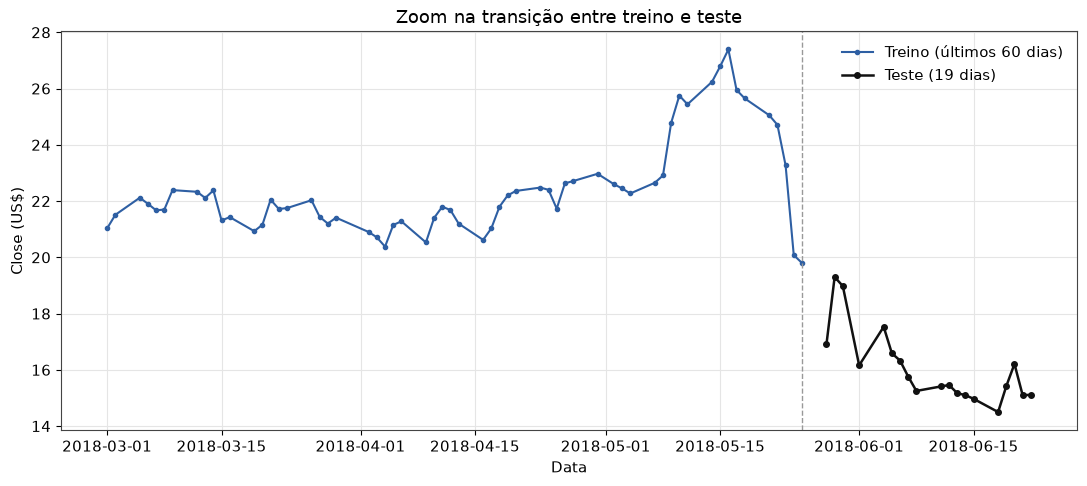

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train["Date"].tail(60), train["Close"].tail(60), color=ut.PALETTE["treino"], linewidth=1.5, marker="o", markersize=3, label="Treino (últimos 60 dias)")
ax.plot(test["Date"], test["Close"], color=ut.PALETTE["real"], linewidth=1.8, marker="o", markersize=4, label="Teste (19 dias)")
ax.axvline(train["Date"].max(), color="#999999", linestyle="--", linewidth=1)
ax.set_title("Zoom na transição entre treino e teste")
ax.set_xlabel("Data"); ax.set_ylabel("Close (US$)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7. Tendência e sazonalidade

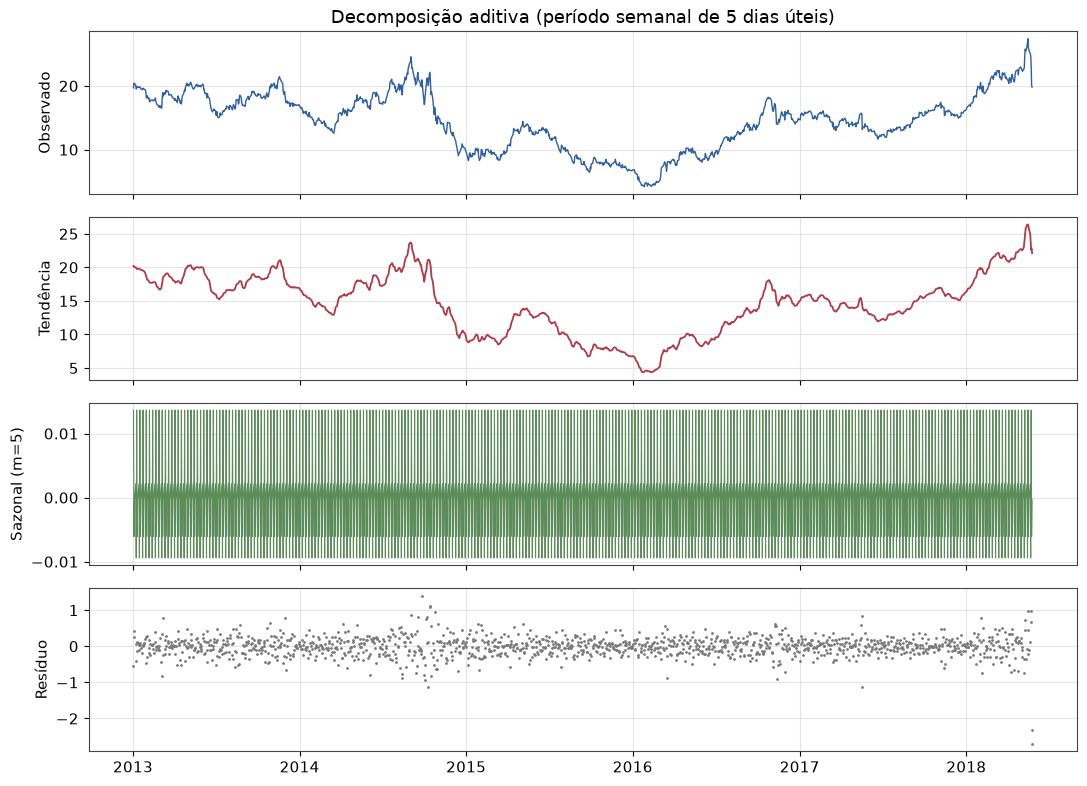

Amplitude da sazonalidade: 0.0231   Amplitude da tendência: 22.04
A sazonalidade semanal representa 0.105% da amplitude da tendência.


In [21]:
s = train.set_index("Date")["Close"].asfreq("B").interpolate(limit_direction="both")
decomp = seasonal_decompose(s, model="additive", period=5, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(decomp.observed, color=ut.PALETTE["treino"], linewidth=1); axes[0].set_ylabel("Observado")
axes[1].plot(decomp.trend, color="#B23A48", linewidth=1.3); axes[1].set_ylabel("Tendência")
axes[2].plot(decomp.seasonal, color="#5B8C5A", linewidth=0.8); axes[2].set_ylabel("Sazonal (m=5)")
axes[3].plot(decomp.resid, color="#7A7A7A", linewidth=0.8, marker=".", markersize=2, linestyle="none"); axes[3].set_ylabel("Resíduo")
axes[0].set_title("Decomposição aditiva (período semanal de 5 dias úteis)")
fig.tight_layout()
plt.show()

amp_sazonal = decomp.seasonal.max() - decomp.seasonal.min()
amp_tendencia = decomp.trend.max() - decomp.trend.min()
print(f"Amplitude da sazonalidade: {amp_sazonal:.4f}   Amplitude da tendência: {amp_tendencia:.2f}")
print(f"A sazonalidade semanal representa {amp_sazonal/amp_tendencia*100:.3f}% da amplitude da tendência.")

* Não foi encontrado um padrão semanal significativo no preço da ação. 
* A variação causada pela sazonalidade é muito pequena (0,0231) quando comparada à variação da tendência (22,04).

## 8. Estacionariedade

In [22]:
close_level = s
adf_level = adfuller(close_level)
print(f"ADF nível: estatística={adf_level[0]:.4f}  p-valor={adf_level[1]:.4f}")

ADF nível: estatística=-1.7633  p-valor=0.3988


O preço de fechamento apresenta comportamento não estacionário.

## 9. Diferenciação

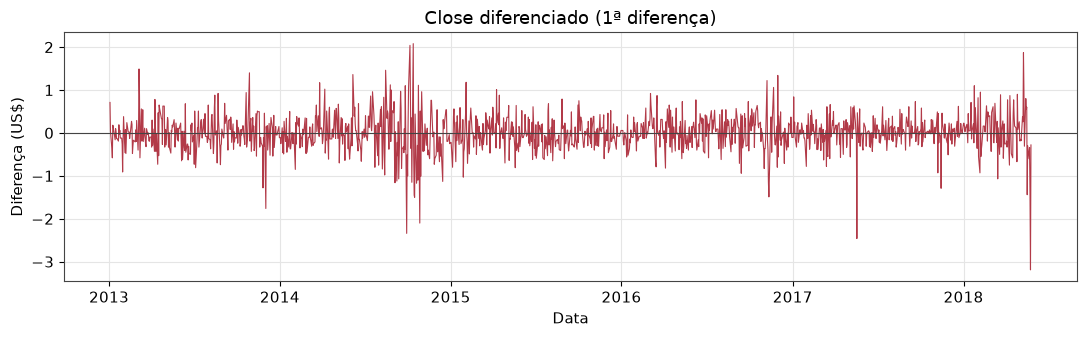

ADF diferença: estatística=-11.9820  p-valor=0.0000


In [23]:
close_diff = s.diff().dropna()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(close_diff.index, close_diff.values, color="#B23A48", linewidth=0.8)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Close diferenciado (1ª diferença)")
ax.set_xlabel("Data"); ax.set_ylabel("Diferença (US$)")
fig.tight_layout()
plt.show()

adf_diff = adfuller(close_diff)
print(f"ADF diferença: estatística={adf_diff[0]:.4f}  p-valor={adf_diff[1]:.4f}")

Após a primeira diferenciação, o p-valor caiu para 0,0000, indicando estacionariedade. 

Considera-se uma diferenciação (d=1) adequada para a modelagem ARIMA.

## 10. ACF e PACF

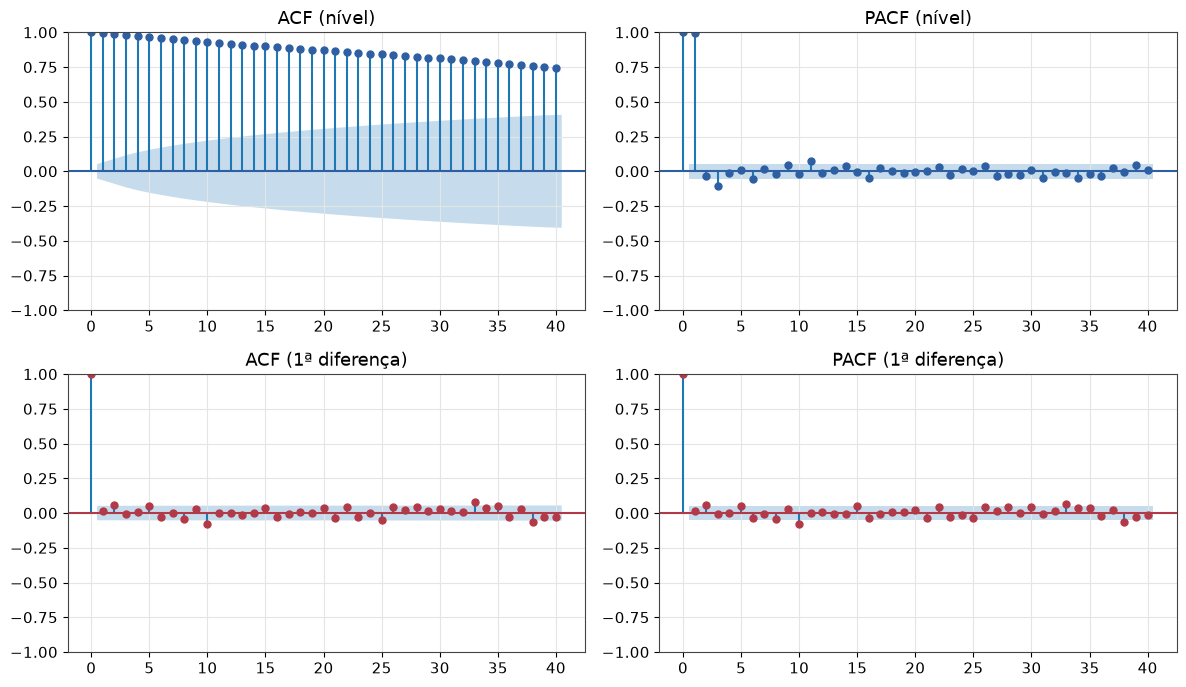

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(close_level, lags=40, ax=axes[0, 0], color=ut.PALETTE["treino"]); axes[0, 0].set_title("ACF (nível)")
plot_pacf(close_level, lags=40, ax=axes[0, 1], color=ut.PALETTE["treino"], method="ywm"); axes[0, 1].set_title("PACF (nível)")
plot_acf(close_diff, lags=40, ax=axes[1, 0], color="#B23A48"); axes[1, 0].set_title("ACF (1ª diferença)")
plot_pacf(close_diff, lags=40, ax=axes[1, 1], color="#B23A48", method="ywm"); axes[1, 1].set_title("PACF (1ª diferença)")
fig.tight_layout()
plt.show()

* ACF no nível: muito alta e decai lentamente → forte autocorrelação e não estacionariedade.

* PACF no nível: pico forte apenas no lag 1 → dependência principalmente do valor anterior.

* ACF na 1ª diferença: valores próximos de zero → a diferenciação reduziu a autocorrelação e tornou a série mais estacionária.

* PACF na 1ª diferença: também próxima de zero → pouca dependência linear entre os retornos/diferenças.

## 11. Validação walk-forward

O modelo prevê o Close para 1, 2 e 3 dias úteis à frente.

A cada dia, a origem avança um dia e as previsões são refeitas usando apenas os dados disponíveis até aquele momento, respeitando a ordem temporal.

In [25]:
origins = ut.walkforward_origins(len(train), len(test), max_h=max(ut.HORIZONS))
print(f"Número de origens de validação: {len(origins)}")
print(f"Primeira origem: {full.loc[origins[0], 'Date'].date()} (prevê {[full.loc[origins[0]+h, 'Date'].date() for h in ut.HORIZONS]})")
print(f"Última origem:   {full.loc[origins[-1], 'Date'].date()} (prevê {[full.loc[origins[-1]+h, 'Date'].date() for h in ut.HORIZONS]})")

Número de origens de validação: 17
Primeira origem: 2018-05-25 (prevê [datetime.date(2018, 5, 28), datetime.date(2018, 5, 29), datetime.date(2018, 5, 30)])
Última origem:   2018-06-19 (prevê [datetime.date(2018, 6, 20), datetime.date(2018, 6, 21), datetime.date(2018, 6, 22)])
